In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os

RAW DATA roztriedené do kategórii 

In [2]:
categorized_data = pd.read_csv("categorized_records.csv")
categorized_data

,Instruction,Input,Output,Category,Subcategory
0,Write a function to find squares of individual...,NaN,def square_nums(nums):\r\n square_nums = list(...,Data Structures,list
1,Create a function in Python which takes a list...,"[3, 4, 5]",def sum_squares(nums):\n result = 0\n fo...,Data Structures,list
2,Design a function in Python that sorts a list ...,"['red', 'green', 'orange']",def sort_list_alphabetically(input_list): \n ...,Sorting,sort
3,Develop a greedy strategy in Python to find th...,NaN,def min_cost(points):\n points.sort() # so...,Mathematics,number
4,Write a Python program to create a singly link...,NaN,"class Node():\n def __init__(self, data):\n ...",Data Structures,linked list
...,...,...,...,...,...
10906,Write a python program that creates and prints...,"Start from 0, increment by 2 and end at 10","for number in range(0, 11, 2):\n print(number)",Syntax,print
10907,Create a web scraper in Python that loads a we...,URL: https://www.example.com/\nText to extract...,import requests\nfrom bs4 import BeautifulSoup...,Data Structures,string
10908,Design an algorithm in Python for finding and ...,100,def find_all_primes(n): \n for num in range(2...,Mathematics,prime
10909,Write a Python program to count words in a sen...,Sentence: “The quick brown fox jumps over the ...,"sentence = ""The quick brown fox jumps over the...",Data Structures,dictionary


In [3]:
categorized_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10911 entries, 0 to 10910
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Instruction  10911 non-null  object
 1   Input        6253 non-null   object
 2   Output       10911 non-null  object
 3   Category     10911 non-null  object
 4   Subcategory  10911 non-null  object
dtypes: object(5)
memory usage: 426.3+ KB


In [4]:
count_category = categorized_data["Category"].value_counts()
count_category

Category
Data Structures                       3563
Mathematics                           2266
Syntax                                1437
Scientific Computing                  1165
Object-Oriented Programming            710
Sorting                                490
Branching                              483
Loops                                  182
Algorithms and Dynamic Programming     172
File Handling                          152
Data Analysis                          109
Functions and Advanced Concepts         96
Testing and Debugging                   86
Name: count, dtype: int64

In [5]:
categorized_data["Subcategory"].unique()

array(['list', 'sort', 'number', 'linked list', 'array', 'print',
       'calculator', 'parameter', 'if', 'calculate', 'fibonacci',
       'string', 'elif', 'stack', 'data structure', 'tree', 'class',
       'read', 'integer', 'dictionary', 'volume', 'user input',
       'nested loop', 'random', 'average', 'multiply', 'sum', 'lambda',
       'sorting', 'loop', 'variable', 'temperature', 'mean', 'error',
       'object', 'matrix', 'date', 'tuple', 'prime', 'continue',
       'for loop', 'median', 'try/except', 'euclidean algorithm',
       'duplicate', 'quicksort algorithm', 'set', 'while', 'optimization',
       'distribution', 'generator', 'pandas', 'memoization', 'hash table',
       'decorator', 'decision', 'for each', 'boolean', 'numpy', 'case',
       'exception', 'histogram', 'file', 'dataframe', 'max', 'debug',
       'unit test', 'queue', 'quick sort', 'plot', 'matplotlib', 'open',
       'condition', 'operator', 'csv', 'min', 'pi', 'analysis', 'close',
       'axis', 'xml', 'v

In [6]:
count_subcategory = categorized_data["Subcategory"].value_counts()

print("Počet otázok v jednotlivých podkategóriách:")
for subcategory, count in count_subcategory.items():
    print(f"{subcategory}: {count} otázok")

Počet otázok v jednotlivých podkategóriách:
list: 1672 otázok
string: 1346 otázok
number: 1098 otázok
print: 840 otázok
calculate: 663 otázok
class: 643 otázok
array: 587 otázok
random: 420 otázok
sort: 389 otázok
if: 358 otázok
dictionary: 308 otázok
sum: 285 otázok
integer: 182 otázok
set: 147 otázok
fibonacci: 140 otázok
duplicate: 121 otázok
read: 108 otázok
loop: 90 otázok
sorting: 89 otázok
tuple: 83 otázok
prime: 73 otázok
elif: 72 otázok
object: 67 otázok
for loop: 65 otázok
data structure: 59 otázok
average: 58 otázok
temperature: 55 otázok
date: 52 otázok
parameter: 48 otázok
pandas: 44 otázok
matrix: 43 otázok
user input: 41 otázok
error: 40 otázok
tree: 35 otázok
variable: 34 otázok
multiply: 31 otázok
stack: 28 otázok
dataframe: 26 otázok
histogram: 24 otázok
decision: 23 otázok
median: 22 otázok
generator: 22 otázok
case: 21 otázok
debug: 21 otázok
lambda: 21 otázok
optimization: 19 otázok
while: 19 otázok
file: 18 otázok
linked list: 18 otázok
mean: 17 otázok
numpy: 15 o

In [7]:
def count_nonempty_lines(output_text):
    if pd.isna(output_text):
        return 0
    return sum(1 for line in output_text.split('\n') if line.strip())

def create_line_count_distribution(dataset):
    line_counts = dataset['Output'].apply(count_nonempty_lines)
    distribution = Counter(line_counts)

    plt.figure(figsize=(10, 6))
    plt.bar(distribution.keys(), distribution.values(), width=0.8)
    plt.title("Distribúcia odpovedí podľa počtu neprázdnych riadkov")
    plt.xlabel("Počet neprázdnych riadkov v odpovedi")
    plt.ylabel("Počet výskytov")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    return distribution

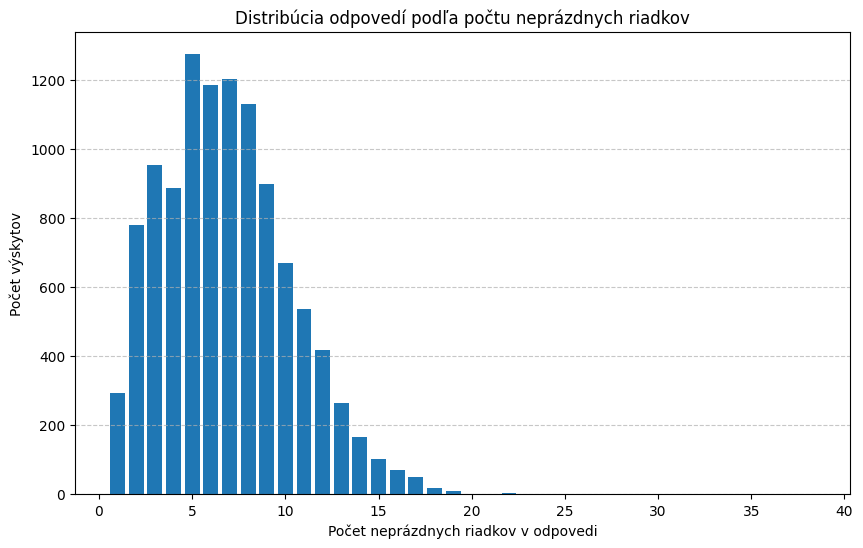

Distribúcia výskytov odpovedí podľa počtu neprázdnych riadkov:
1 riadkov: 292 odpovedí
2 riadkov: 780 odpovedí
3 riadkov: 953 odpovedí
4 riadkov: 887 odpovedí
5 riadkov: 1274 odpovedí
6 riadkov: 1186 odpovedí
7 riadkov: 1202 odpovedí
8 riadkov: 1129 odpovedí
9 riadkov: 897 odpovedí
10 riadkov: 670 odpovedí
11 riadkov: 535 odpovedí
12 riadkov: 419 odpovedí
13 riadkov: 265 odpovedí
14 riadkov: 167 odpovedí
15 riadkov: 101 odpovedí
16 riadkov: 70 odpovedí
17 riadkov: 49 odpovedí
18 riadkov: 19 odpovedí
19 riadkov: 8 odpovedí
20 riadkov: 2 odpovedí
21 riadkov: 1 odpovedí
22 riadkov: 3 odpovedí
26 riadkov: 1 odpovedí
38 riadkov: 1 odpovedí


In [8]:
distribution = create_line_count_distribution(categorized_data)

print("Distribúcia výskytov odpovedí podľa počtu neprázdnych riadkov:")
for line_count, count in sorted(distribution.items()):
    print(f"{line_count} riadkov: {count} odpovedí")

In [9]:
def questions_with_long_outputs(dataset, min_lines=15):
    # Filtrujeme otázky podľa počtu neprázdnych riadkov v odpovedi
    for index, row in dataset.iterrows():
        output_text = row['Output']
        if pd.notna(output_text):
            line_count = sum(1 for line in output_text.split('\n') if line.strip())
            if line_count > min_lines:
                print(f"Otázka (Instruction):\n{row['Instruction']}")
                print(f"Kategória a Podkategória:\n{row['Category'],row['Subcategory']}")
                print(f"Počet neprázdnych riadkov: {line_count}")
                print("-" * 50)

Separácia otázok s dlhou odpoveďou

In [10]:
def questions_with_long_outputs(dataset, output_file="long_output_questions.csv", min_lines=15):

    long_output_questions = []
    for index, row in dataset.iterrows():
        output_text = row['Output']
        if pd.notna(output_text): 
            line_count = sum(1 for line in output_text.split('\n') if line.strip())  
            if line_count > min_lines:
                long_output_questions.append({
                    "Instruction": row['Instruction'],
                    "Input": row['Input'],
                    "Output": output_text,
                    "Category": row['Category'],
                    "Subcategory": row['Subcategory']
                })

    if long_output_questions:
        long_output_df = pd.DataFrame(long_output_questions)
        long_output_df.to_csv(output_file, index=False)
        print(f"Otázky s výstupmi dlhšími ako {min_lines} riadkov boli uložené do súboru: {output_file}")
    else:
        print(f"Nenašli sa žiadne otázky s výstupmi dlhšími ako {min_lines} riadkov.")

In [11]:
questions_with_long_outputs(categorized_data, output_file="long_output_questions.csv", min_lines=15)

Otázky s výstupmi dlhšími ako 15 riadkov boli uložené do súboru: long_output_questions.csv


In [12]:
for_delete= pd.read_csv("long_output_questions.csv")

In [13]:
for_delete.count()

Instruction    154
Input           67
Output         154
Category       154
Subcategory    154
dtype: int64

In [14]:
count_subcategory1 = for_delete["Subcategory"].value_counts()

print("Počet otázok v jednotlivých podkategóriách:")
for subcategory, count in count_subcategory1.items():
    print(f"{subcategory}: {count} otázok")

Počet otázok v jednotlivých podkategóriách:
print: 41 otázok
fibonacci: 18 otázok
number: 15 otázok
list: 12 otázok
calculate: 9 otázok
class: 7 otázok
if: 6 otázok
prime: 5 otázok
stack: 5 otázok
string: 5 otázok
integer: 4 otázok
sum: 4 otázok
array: 3 otázok
set: 3 otázok
dictionary: 2 otázok
median: 2 otázok
data structure: 2 otázok
elif: 2 otázok
calculator: 1 otázok
plot: 1 otázok
read: 1 otázok
pi: 1 otázok
linked list: 1 otázok
error: 1 otázok
loop: 1 otázok
user input: 1 otázok
min: 1 otázok


Vytvorenie FILTERED datasetu 

In [15]:

filtered_data = categorized_data[~categorized_data['Instruction'].isin(for_delete['Instruction'])]

print(f"Počet záznamov pred odstránením: {len(categorized_data)}")
print(f"Počet záznamov po odstránení: {len(filtered_data)}")


Počet záznamov pred odstránením: 10911
Počet záznamov po odstránení: 10756


In [16]:
newdataset = filtered_data
if os.path.exists("filtered_data.csv"):
    os.remove("filtered_data.csv")
    print("Starý súbor 'filtered_data.csv' bol odstránený.")
output_file = "filtered_data.csv"
newdataset.to_csv(output_file, index=False)
print(f"Dataset bol uložený do súboru: {output_file}")
print("-" * 50)

Starý súbor 'filtered_data.csv' bol odstránený.
Dataset bol uložený do súboru: filtered_data.csv
--------------------------------------------------


FILTROVANÉ DÁTA

In [17]:
filtered_dataset = pd.read_csv("filtered_data.csv")

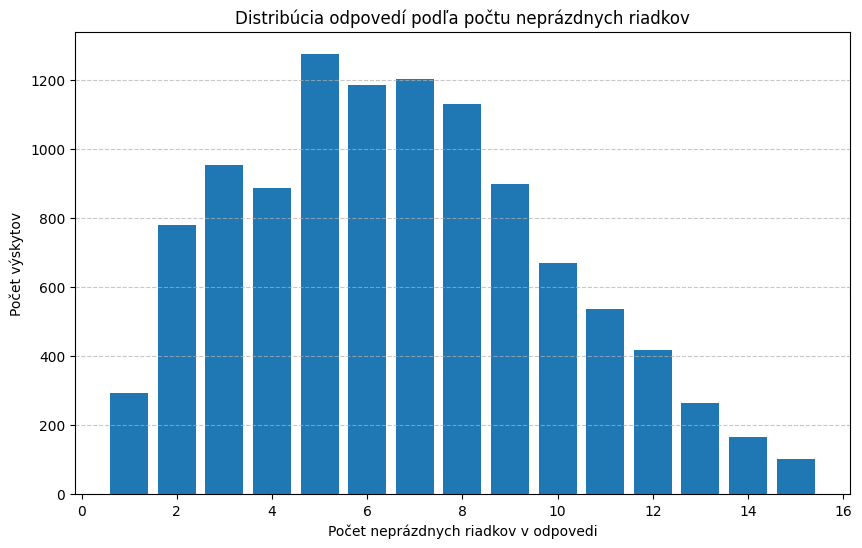

Distribúcia výskytov odpovedí podľa počtu neprázdnych riadkov:
1 riadkov: 292 odpovedí
2 riadkov: 780 odpovedí
3 riadkov: 953 odpovedí
4 riadkov: 887 odpovedí
5 riadkov: 1274 odpovedí
6 riadkov: 1186 odpovedí
7 riadkov: 1202 odpovedí
8 riadkov: 1129 odpovedí
9 riadkov: 897 odpovedí
10 riadkov: 669 odpovedí
11 riadkov: 535 odpovedí
12 riadkov: 419 odpovedí
13 riadkov: 265 odpovedí
14 riadkov: 167 odpovedí
15 riadkov: 101 odpovedí


In [18]:
distribution2 = create_line_count_distribution(filtered_dataset)

print("Distribúcia výskytov odpovedí podľa počtu neprázdnych riadkov:")
for line_count, count in sorted(distribution2.items()):
    print(f"{line_count} riadkov: {count} odpovedí")

In [19]:
count_category_filtered_data = filtered_dataset["Category"].value_counts()
count_category_filtered_data

Category
Data Structures                       3535
Mathematics                           2230
Syntax                                1388
Scientific Computing                  1161
Object-Oriented Programming            703
Sorting                                490
Branching                              475
Loops                                  181
Algorithms and Dynamic Programming     154
File Handling                          151
Data Analysis                          107
Functions and Advanced Concepts         96
Testing and Debugging                   85
Name: count, dtype: int64

In [20]:
filtered_dataset["Subcategory"].unique()

array(['list', 'sort', 'number', 'array', 'print', 'calculator',
       'parameter', 'if', 'calculate', 'fibonacci', 'string', 'elif',
       'stack', 'data structure', 'tree', 'class', 'read', 'integer',
       'dictionary', 'volume', 'user input', 'nested loop', 'random',
       'average', 'multiply', 'sum', 'lambda', 'sorting', 'loop',
       'variable', 'temperature', 'mean', 'error', 'object', 'matrix',
       'date', 'tuple', 'prime', 'continue', 'for loop', 'median',
       'try/except', 'euclidean algorithm', 'duplicate',
       'quicksort algorithm', 'set', 'while', 'optimization',
       'distribution', 'linked list', 'generator', 'pandas',
       'memoization', 'hash table', 'decorator', 'decision', 'for each',
       'boolean', 'numpy', 'case', 'exception', 'histogram', 'file',
       'dataframe', 'max', 'debug', 'unit test', 'queue', 'quick sort',
       'plot', 'matplotlib', 'open', 'condition', 'operator', 'csv',
       'min', 'pi', 'analysis', 'close', 'axis', 'xml', 'v

In [21]:
count_subcategory_filtered_data  = filtered_dataset["Subcategory"].value_counts()

print("Počet otázok v jednotlivých podkategóriách:")
for subcategory, count in count_subcategory_filtered_data.items():
    print(f"{subcategory}: {count} otázok")

Počet otázok v jednotlivých podkategóriách:
list: 1659 otázok
string: 1341 otázok
number: 1083 otázok
print: 799 otázok
calculate: 654 otázok
class: 636 otázok
array: 584 otázok
random: 420 otázok
sort: 389 otázok
if: 352 otázok
dictionary: 306 otázok
sum: 281 otázok
integer: 178 otázok
set: 144 otázok
fibonacci: 122 otázok
duplicate: 121 otázok
read: 107 otázok
sorting: 89 otázok
loop: 89 otázok
tuple: 83 otázok
elif: 70 otázok
prime: 68 otázok
object: 67 otázok
for loop: 65 otázok
average: 58 otázok
data structure: 57 otázok
temperature: 55 otázok
date: 52 otázok
parameter: 48 otázok
pandas: 44 otázok
matrix: 43 otázok
user input: 40 otázok
error: 39 otázok
tree: 35 otázok
variable: 34 otázok
multiply: 31 otázok
dataframe: 26 otázok
histogram: 24 otázok
decision: 23 otázok
stack: 23 otázok
generator: 22 otázok
debug: 21 otázok
case: 21 otázok
lambda: 21 otázok
median: 20 otázok
optimization: 19 otázok
while: 19 otázok
file: 18 otázok
linked list: 17 otázok
mean: 17 otázok
numpy: 15 o